<a href="https://colab.research.google.com/github/andryowiniciusac-creator/learning-course-linea/blob/main/Aula_4_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 4 - Visualização de dados



### Objetivo: Color-magnitude diagram (CMD) de galáxias

Depois de explorar os comandos para criar e customizar gráficos básicos, ao final do notebook faremos um diagrama cor-magnitude de galáxias com dados observacionais do levantamento DES (Y1). Esta amostra faz parte do produto da publicação [Aguena et al. 2021](https://academic.oup.com/mnras/article-abstract/502/3/4435/6137813?redirectedFrom=PDF) e estão disponíveis para download no repositório de produtos científicos [LIneA Dataverse](https://dataverse.linea.gov.br/dataset.xhtml?persistentId=doi:10.5072/FK2/WQQOBC).

No arquivo `cluster_members.csv` dentro da pasta `dados` vamos encontrar um catálogo de objetos classificados como membros de aglomerados de galáxias com alto valor de "riqueza", ou seja, que possuem muitos membros (neste caso > 250 membros).  


#### "_Caveats_" e adaptações necessárias:

+ Conjunto de filtros disponíveis no DES: filtros $grizY$. Usaremos então as cores $g-r$ ou $g-i$.
+ O redshift fotométrico (photo-$z$) é utilizado como um indicador de distância (redshift cosmológico).


## 0. Setup

In [ ]:
import numpy as np
import pandas as pd # sua construção foi baseada no Numpy
import matplotlib.pyplot as plt
import seaborn as sns # sua construção foi baseada no Matplotlib

%matplotlib inline
# Comando mágico

**Leitura dos dados**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

clusters = "/content/drive/MyDrive/cluster_members.csv"
# importando o arquivo do drive para o colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dados = pd.read_csv("/content/drive/MyDrive/cluster_members.csv")
# Pandas vai associa a variável dados à um DataFrame
# Leitura de dados

In [ ]:
dados.head()

,obj_id,ra,dec,z_gal,z_cluster,n_gals,mag_g,mag_r,mag_i,mag_z,mag_y
0,161155,43.687638,-58.985581,0.483762,0.421065,263.8428,23.253954,22.224186,22.088303,22.003595,22.561129
1,161156,43.627321,-58.833762,0.573784,0.421065,263.8428,22.958794,22.013378,21.562824,21.240536,20.883377
2,161157,43.550251,-58.979774,0.415583,0.421065,263.8428,22.091076,20.356499,19.780567,19.422976,19.240734
3,161158,43.761604,-58.938851,0.552824,0.421065,263.8428,21.797768,21.155682,20.791380,20.776703,20.670448
4,161159,43.600389,-58.909786,0.407436,0.421065,263.8428,22.366661,20.615086,20.053463,19.695760,19.527836


z_gal e z_cluster (ou somente z_) são os redshifts fotométricosda galáxia e do aglomerado respectivamente

n_gal é o número de galáxias no aglomerado; pode ser um número fracionário porque a forma com que o aglomerado é definido aqui é baseado em probabilidades

mag são as magnitudes nas bandas g, r, i, z, y


In [ ]:
dados.size # Tamanho do catálogo (colunas)

21230

In [ ]:
dados.info() # Ficha técnica do DataFrane; Non-Null Count indica número de linhas por coluna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   obj_id     1930 non-null   int64  
 1   ra         1930 non-null   float64
 2   dec        1930 non-null   float64
 3   z_gal      1930 non-null   float64
 4   z_cluster  1930 non-null   float64
 5   n_gals     1930 non-null   float64
 6   mag_g      1930 non-null   float64
 7   mag_r      1930 non-null   float64
 8   mag_i      1930 non-null   float64
 9   mag_z      1930 non-null   float64
 10  mag_y      1930 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 166.0 KB


In [ ]:
dados.describe() # Descrição das estatísticas básicas

,obj_id,ra,dec,z_gal,z_cluster,n_gals,mag_g,mag_r,mag_i,mag_z,mag_y
count,1.930000e+03,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000
mean,6.846419e+05,142.614130,-50.410572,0.583508,0.556269,269.220057,23.467658,22.126449,21.501311,21.225393,22.606584
std,7.518509e+05,152.866052,6.959484,0.120721,0.108806,12.644711,1.027661,0.936361,0.900371,0.985559,10.595915
min,1.611550e+05,20.687670,-59.054022,0.353152,0.421065,256.105200,20.369429,18.746170,18.131592,17.727472,17.524618
25%,1.616372e+05,20.861044,-58.931198,0.482361,0.421065,256.105200,22.803102,21.511842,20.904466,20.573159,20.411901
50%,2.563025e+05,43.611300,-48.359904,0.577368,0.601264,263.842800,23.449534,22.194900,21.597273,21.300897,21.178892
75%,1.862891e+06,356.158417,-42.746426,0.679608,0.678612,286.370330,24.082624,22.794204,22.174445,21.935405,21.883245
max,1.863373e+06,356.299955,-42.634894,0.857235,0.678612,286.370330,28.984634,25.881884,22.996027,23.776173,99.000000


# 1. Gráficos com a biblioteca Matplotlib

[matplotlib.org](https://matplotlib.org/)

[cheatsheets](https://github.com/matplotlib/cheatsheets#cheatsheets)

## 1.1 Histogramas (1D)

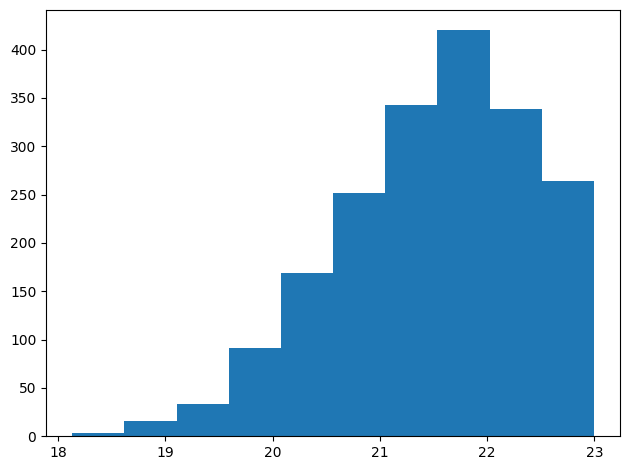

In [ ]:
plt.hist(dados.mag_i)
plt.tight_layout() # Bom para salvar isso em uma figura para usar em outro lugar
# o titht_layout() é interessante para não deixar margens

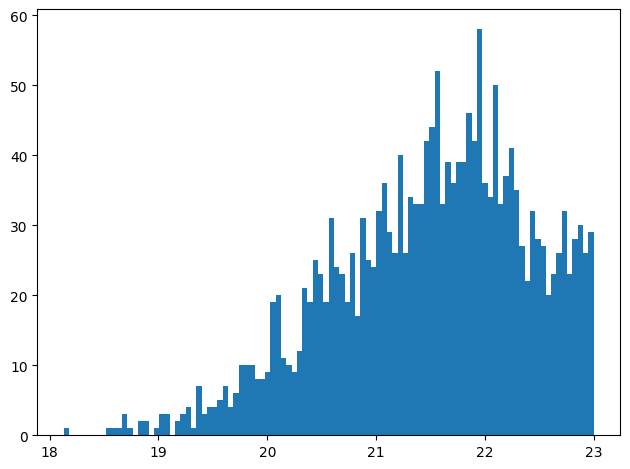

In [ ]:
plt.hist(dados.mag_i, bins=100) # bins serve para ter maior resolução nesse histograma
plt.tight_layout()

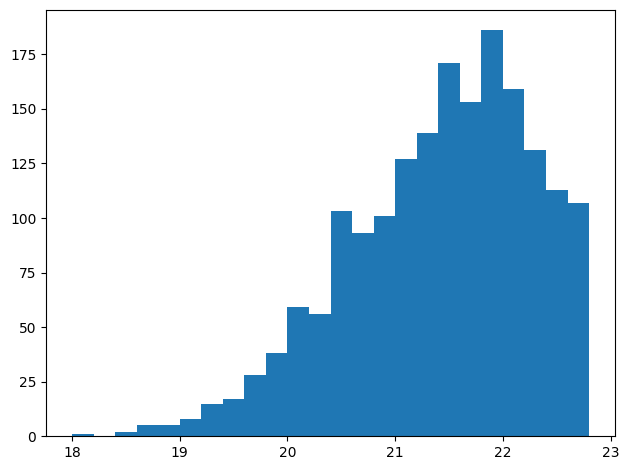

In [ ]:
# Uma outra maneira de determinar os bins é fazer uma sequência/lista
# Dizer quais são as bordas dos bins
plt.hist(dados.mag_i, bins=np.arange(18, 23, 0.2)) # Começando em 18 e terminando em 23 (eixo x), a largura foi definida como 0.2
plt.tight_layout()

Um bin muito largo esconde os detalhes

Um bin muito fino fica muito ruidoso

O tamanho ideal é definido pela regra de Freedman-Diaconis

**Freedman–Diaconis rule**

Regra da estatística para calcular a largura de bin ótima para exibir uma distribuição de dados. Fonte: [Wikipedia](https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule)



$$ bin \ width = 2 \  \frac{Q_{3}-Q_{1}}{\sqrt[3]{N}}  $$








Ela depende do terceiro (Q3) e do primeiro (Q1) quartil

1º Quartil (25%)
2º Quartil ou Mediana (50%)
3º Quartil (75%)

In [ ]:
q1, q2, q3 = dados.mag_i.quantile(q=[0.25, 0.50, 0.75])
# Vamos analisar quais são os quartis q1, q2, q3 da coluna mag_i
# Usamos o método quantile, e digo quais são os quantiles
q1, q2, q3 # Armazenamos nas variáveis q1, q2 e q3

(20.90446575, 21.597273, 22.174445)

In [ ]:
def bin_width(series): # Se quisermos fazer isso para outras colunas
    """Return optimal bin width for a given pandas Series
        object based on the Freedman–Diaconis rule"""

    q1, q3 = series.quantile(q=[0.25, 0.75]) # Fazemos a mesma coisa só com os 25 e 75
    width = 2 * ((q3-q1)/(series.count()**(1./3.))) # A fórmula

    return width # O resultado disso é a largura do bin
# Ao definir a função, podemos reusar em outras Series

In [ ]:
bin_width(dados.mag_i) #aplicando na coluna mag_i

np.float64(0.20400501849285146)

In [ ]:
bin_width(dados.mag_g)

np.float64(0.2055378521101828)

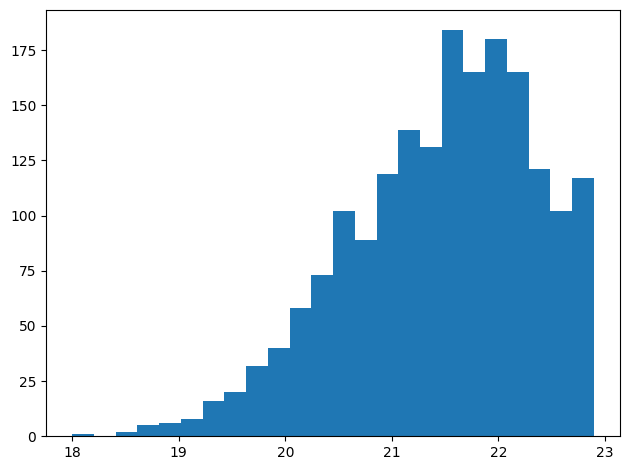

In [ ]:
plt.hist(dados.mag_i, bins=np.arange(18, 23, bin_width(dados.mag_i))) # Aplicamos a função definida anteriomente e usamos a mesma variável usada para o histograma
plt.tight_layout()

In [ ]:
help(plt.hist)

Help on function hist in module matplotlib.pyplot:

hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, *, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distribution ei

In [ ]:
help(np.histogram_bin_edges)

Help on _ArrayFunctionDispatcher in module numpy:

histogram_bin_edges(a, bins=10, range=None, weights=None)
    Function to calculate only the edges of the bins used by the `histogram`
    function.

    Parameters
    ----------
    a : array_like
        Input data. The histogram is computed over the flattened array.
    bins : int or sequence of scalars or str, optional
        If `bins` is an int, it defines the number of equal-width
        bins in the given range (10, by default). If `bins` is a
        sequence, it defines the bin edges, including the rightmost
        edge, allowing for non-uniform bin widths.

        If `bins` is a string from the list below, `histogram_bin_edges` will
        use the method chosen to calculate the optimal bin width and
        consequently the number of bins (see the Notes section for more detail
        on the estimators) from the data that falls within the requested range.
        While the bin width will be optimal for the actual data
  

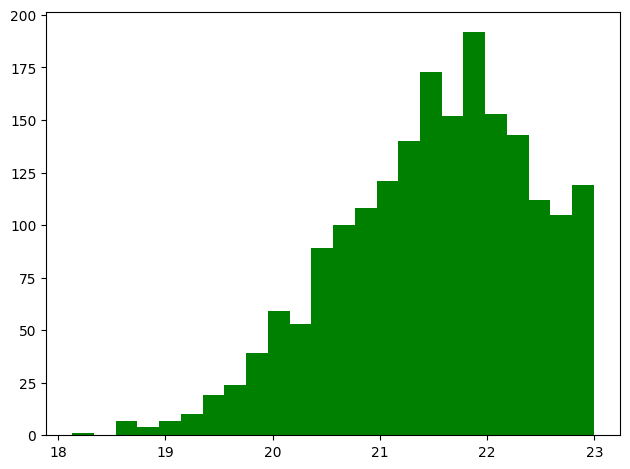

In [ ]:
plt.hist(dados.mag_i, bins="fd", color="g") # Já dá pra fazer todo esse processo de forma direta com simplesmete bins="fd"
plt.tight_layout() # Dá pra usar "green" ou "g" no color=
# Algumas mudam e não são intuitivas, como a cor preta (k), já que b é azul


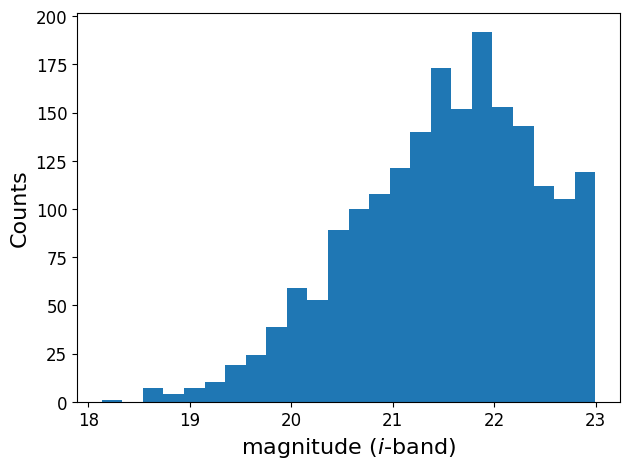

In [ ]:
plt.hist(dados.mag_i, bins="fd")
plt.xlabel("magnitude ($i$-band)", fontsize="16") # nome do eixo x; $$ é escrita em latex
plt.ylabel("Counts", fontsize="16") # Tamanho da fonte: fontsize=""
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.tight_layout()

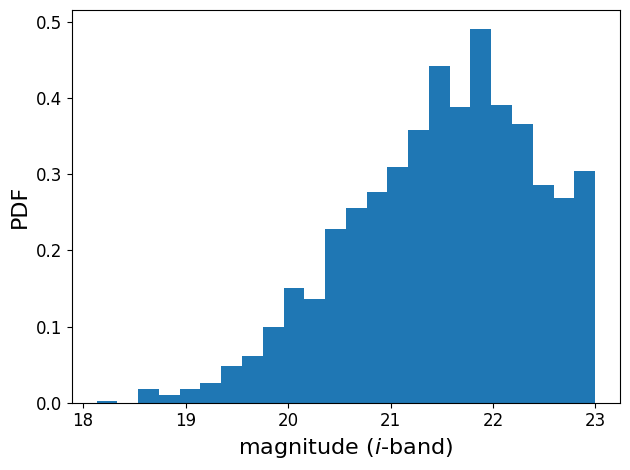

In [ ]:
plt.hist(dados.mag_i, bins="fd", density=True) # virou uma função de densidade de probabilidade
plt.xlabel("magnitude ($i$-band)", fontsize="16")
plt.ylabel("PDF", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.tight_layout()

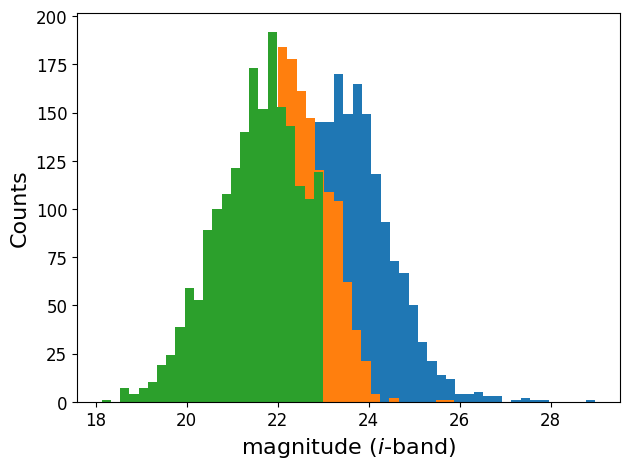

In [ ]:
plt.hist(dados.mag_g, bins="fd")
plt.hist(dados.mag_r, bins="fd")
plt.hist(dados.mag_i, bins="fd")
plt.xlabel("magnitude ($i$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.tight_layout()
# Podemos colocar mais de um histograma por gráfico

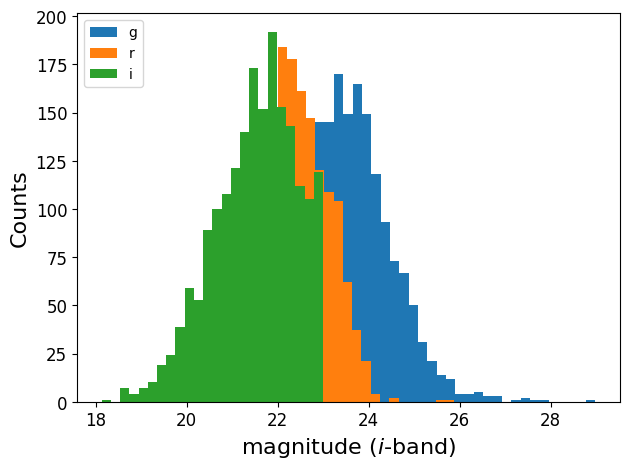

In [ ]:
for band in ["g", "r", "i"]: # Usando for
  plt.hist(dados[f"mag_{band}"], bins="fd", label=band) # Colocar um label, que é a banda
plt.xlabel("magnitude ($i$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.legend(loc="upper left") # Para o label aparecer, precisa chamar uma legenda
plt.tight_layout()
# Podemos colocar mais de um histograma por gráfico
# Dá pra trocar a posição da legenda
# Em ordem: upper left, upper right
# Em ordem: bottom left, bottom left

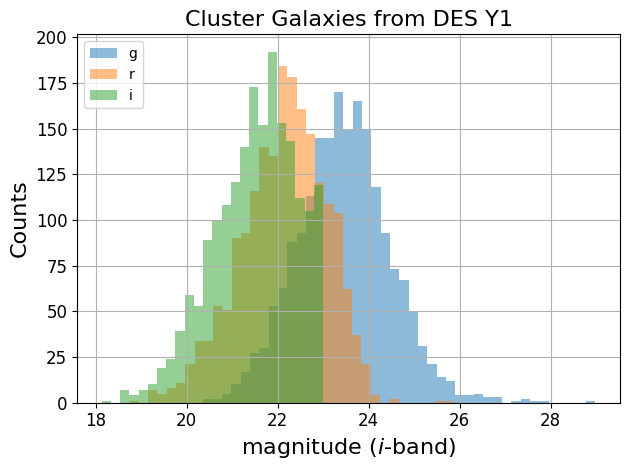

In [ ]:
for band in ["g", "r", "i"]:
  plt.hist(dados[f"mag_{band}"], bins="fd", label=band, alpha=0.5) # Quanto menor o alpha, mais transparente. Quando = 1.0 é opaco
plt.xlabel("magnitude ($i$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.legend(loc="upper left")
plt.grid() # Grade, para orientar os eixos
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.tight_layout()

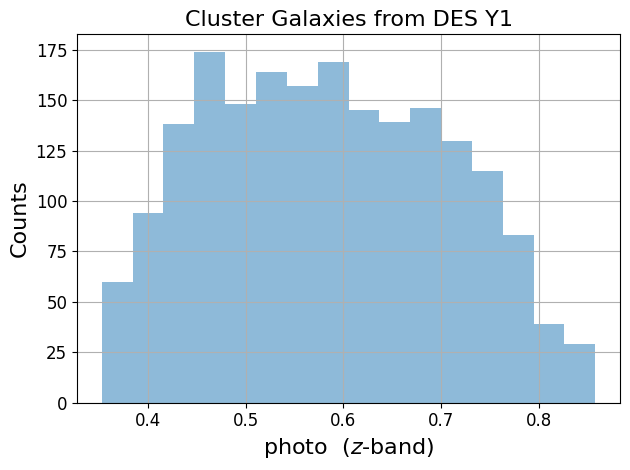

In [ ]:
plt.hist(dados.z_gal, bins="fd", alpha=0.5) # Quanto menor o alpha, mais transparente. Quando = 1.0 é opaco
plt.xlabel("photo  ($z$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.grid() # Grade, para orientar os eixos
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.tight_layout()

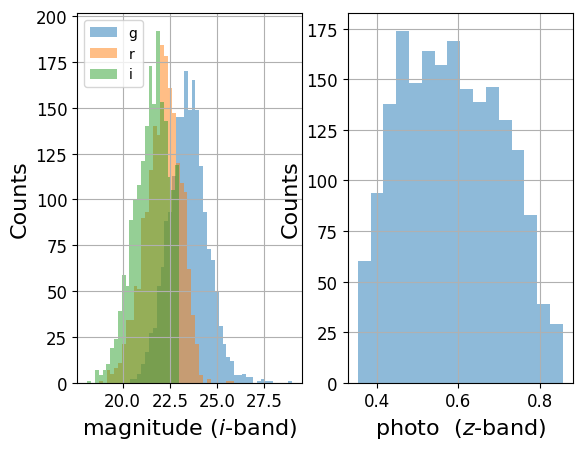

In [ ]:
# Plotando os dois histogramas na mesma figura, um do lado do outro
plt.subplot(1,2,1) # Respectivamente, número de linhas, número de colunas e o primeiro ou segundo ou terceiro plot
for band in ["g", "r", "i"]:
  plt.hist(dados[f"mag_{band}"], bins="fd", label=band, alpha=0.5) # Quanto menor o alpha, mais transparente. Quando = 1.0 é opaco
plt.xlabel("magnitude ($i$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.legend(loc="upper left")
plt.grid()

plt.subplot(1,2,2)
plt.hist(dados.z_gal, bins="fd", alpha=0.5)
plt.xlabel("photo  ($z$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.grid()

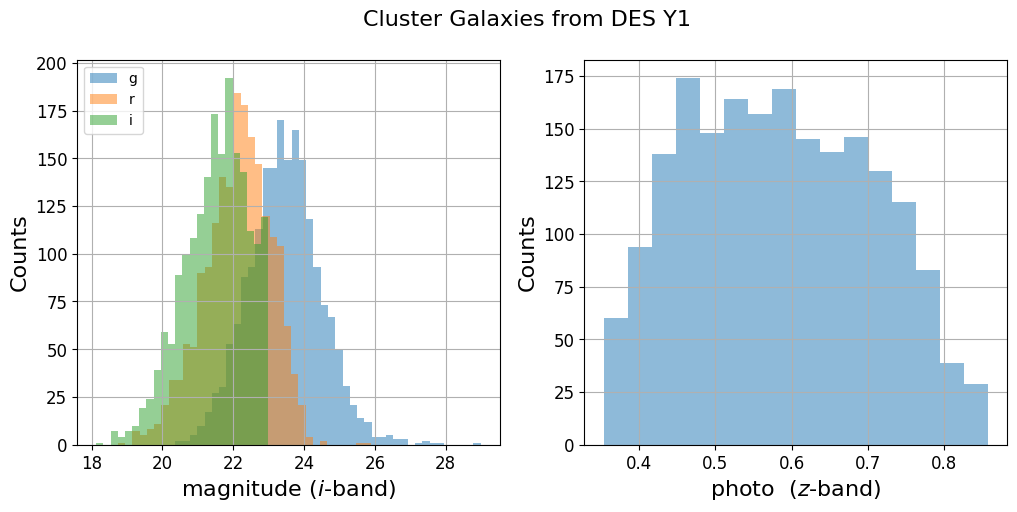

In [ ]:
# Ficou muito estreito para a largura das figuras, vamos arrumar
plt.figure(figsize=[12, 5], dpi=100) # dpi é a qualidade da figura; para artigos é bom ter dpi/qualdiade alta
# figsize=[eixoX, eixoY]; tamanho da figura
plt.subplot(1,2,1)
for band in ["g", "r", "i"]:
  plt.hist(dados[f"mag_{band}"], bins="fd", label=band, alpha=0.5)
plt.xlabel("magnitude ($i$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.legend(loc="upper left")
plt.grid()

plt.subplot(1,2,2)
plt.hist(dados.z_gal, bins="fd", alpha=0.5)
plt.xlabel("photo  ($z$-band)", fontsize="16")
plt.ylabel("Counts", fontsize="16")
plt.xticks(fontsize="12")
plt.yticks(fontsize="12")
plt.grid()

plt.suptitle("Cluster Galaxies from DES Y1", fontsize=16) # Super título, comum aos dois histogranas
# Satisfeito com a figura, vamos salvar para publicação
plt.savefig("mag_and_z_distribuitions.pdf") # pode ser jpeg, png, PDF

## 1.2 Plot (xy) and Scatter plots

Plot

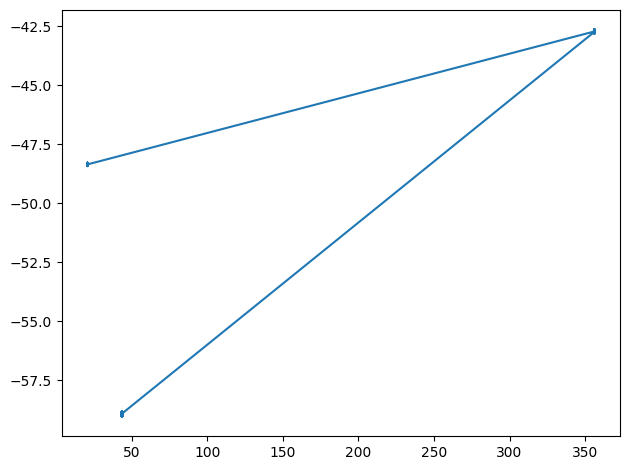

In [ ]:
# Duas variávels ao invés de uma só
plt.plot(dados.ra, dados.dec)
plt.tight_layout()
# Vemos 3 pontos ligados por retas
# O default é ligar os pontos por retas, e é possível mudar isso

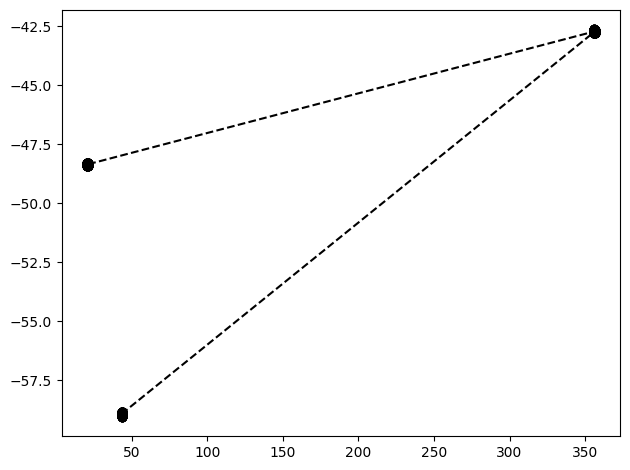

In [ ]:
plt.plot(dados.ra, dados.dec, "ko--") # 3 caracteres: cor, símbolo do marcador e linha respectivamente
# O terceiro argumento é onde você coloca qual é símbolo do marcador e qual a linha que liga eles, se tiver linha
plt.tight_layout()

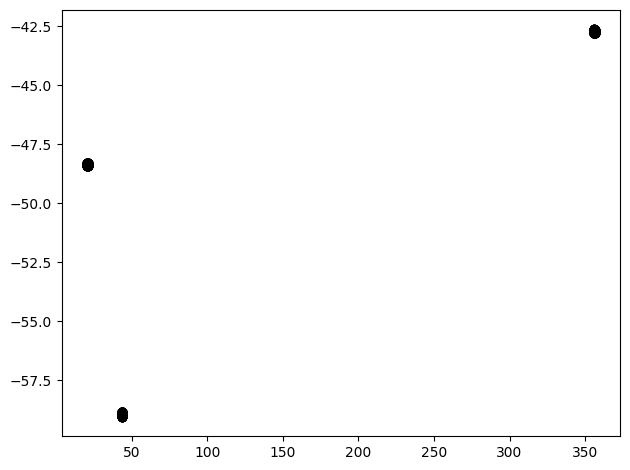

In [ ]:
plt.plot(dados.ra, dados.dec, "ko") # Sem linha
plt.tight_layout()
# Parece que tem 3 pontos, mas na verdade são 3 amontoados de pontos
# A amostra tem 3 aglomerados de galáxias

In [ ]:
# Vamos dividir os clusters e ver mais detalhes
cluster1 = dados.query("ra > 300")
cluster1 # DataFrame com qualquer 1, mas é um recorte daqueles dados

,obj_id,ra,dec,z_gal,z_cluster,n_gals,mag_g,mag_r,mag_i,mag_z,mag_y
721,256059,356.274267,-42.732749,0.598197,0.601264,286.37033,24.362362,22.888659,22.165554,22.155266,22.771273
722,256060,356.282388,-42.715923,0.757574,0.601264,286.37033,22.432718,21.721200,21.019627,20.858925,20.811186
723,256061,356.271765,-42.686206,0.792110,0.601264,286.37033,23.427021,22.842266,22.146034,22.071026,21.600624
724,256062,356.103382,-42.773335,0.521214,0.601264,286.37033,22.598335,21.445961,20.918964,20.547590,20.604640
725,256063,356.081363,-42.742596,0.620514,0.601264,286.37033,22.648048,21.456497,20.728577,20.460120,20.251413
...,...,...,...,...,...,...,...,...,...,...,...
1368,256706,356.176107,-42.677720,0.756161,0.601264,286.37033,24.054192,22.920120,22.012608,21.690100,21.073738
1369,256707,356.166147,-42.670596,0.720973,0.601264,286.37033,23.856060,22.181700,21.242592,20.702090,20.653427
1370,256708,356.139942,-42.664313,0.610794,0.601264,286.37033,23.896614,23.133270,22.780117,22.507784,27.285511
1371,256709,356.162212,-42.730141,0.750763,0.601264,286.37033,25.652748,24.034615,22.815950,22.756271,24.784498


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

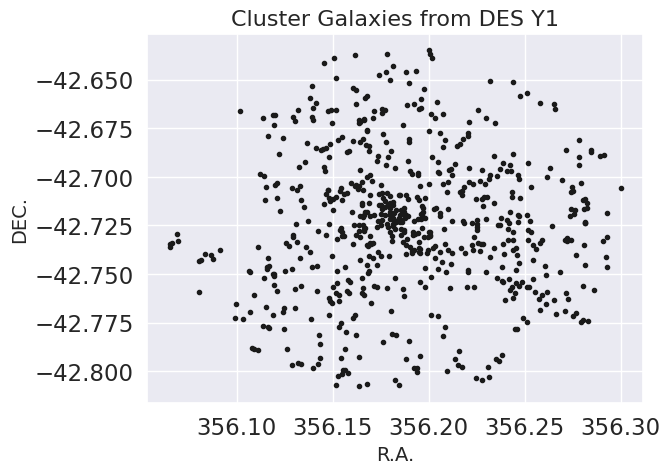

In [156]:
plt.figure(dpi=100)
plt.plot(cluster1.ra, cluster1.dec, "k.")
# podemos mudar esse "ko", colocando rq para quadrados vermelhos, gˆ para triângulo
# Para daltônicos é ideal mudar o formato para não depender apenas da cor
# k. para ponto preto e menor que o círculo
# k, para ponto preto muito menor que o círculo
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

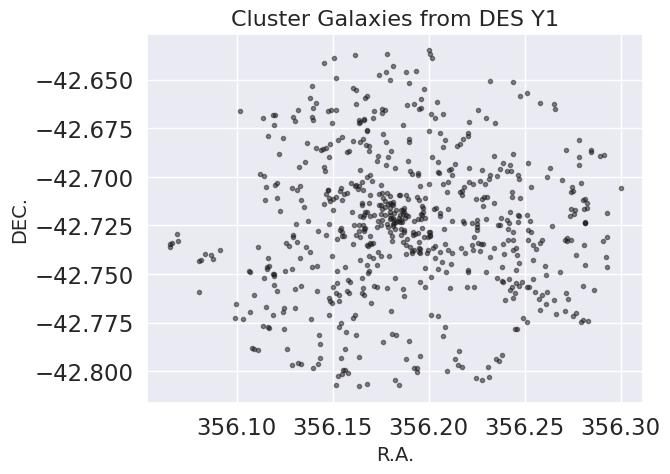

In [147]:
plt.figure(dpi=100)
plt.plot(cluster1.ra, cluster1.dec, "k.", alpha=0.5)
# Existe formas mais robustas de fazer isso, mas pode saber onde fica as regiões com maior densidade, usando alpha
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.tight_layout

Scatter plot

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

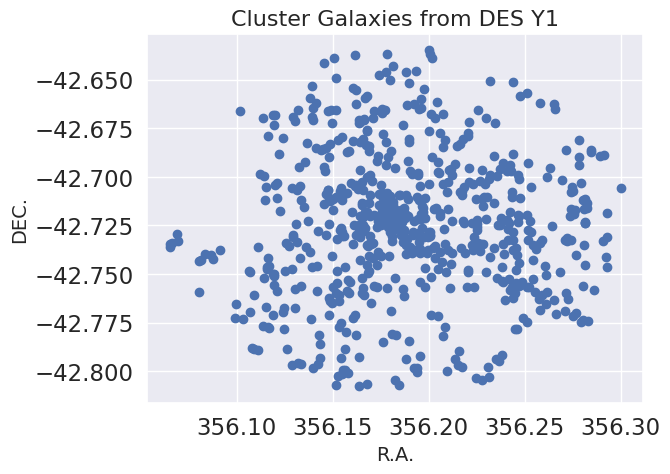

In [148]:
# Scatter plot nos dá mais liberdade de customizar individualmente cada um dos pontos
plt.figure(dpi=100)
plt.scatter(cluster1.ra, cluster1.dec) # Ao invés de plot usa scatter
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

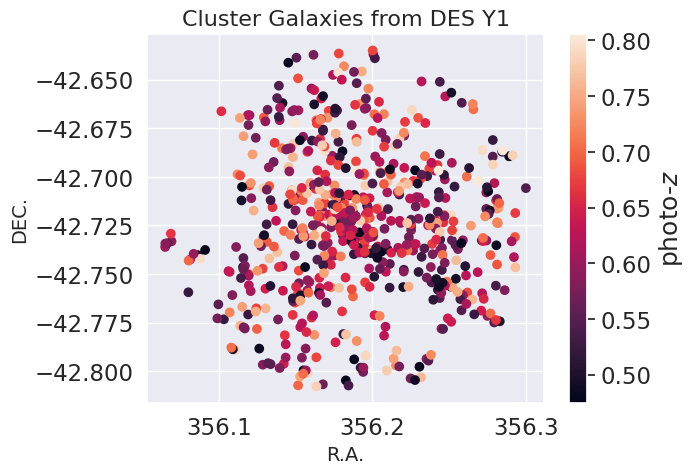

In [149]:
plt.figure(dpi=100)
plt.scatter(cluster1.ra, cluster1.dec, c=cluster1.z_gal) # colocamos o argumento da cor (c=)
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.colorbar(label="photo-$z$") # coloca a colorbar ao lado referente ao redshift fotométrico
plt.tight_layout

## 1.3 Density plots

In [ ]:
from scipy.stats import gaussian_kde

CPU times: user 81.2 ms, sys: 2.86 ms, total: 84.1 ms
Wall time: 45.8 ms


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

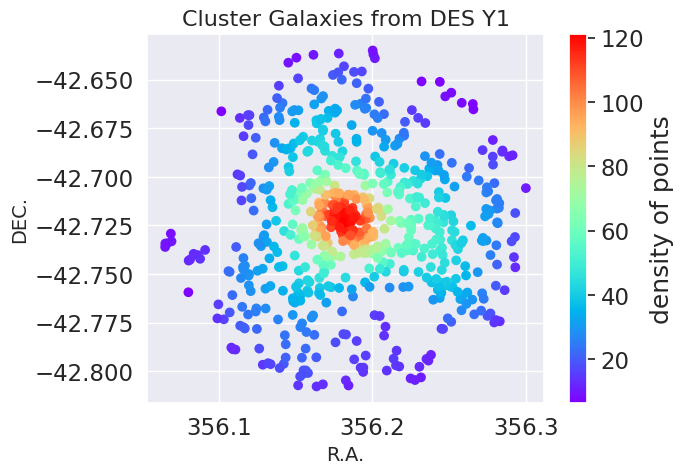

In [150]:
%%time
xy = np.vstack([cluster1.ra, cluster1.dec])
density = gaussian_kde(xy)(xy)
plt.figure(dpi=100)
plt.scatter(cluster1.ra, cluster1.dec, c=density, cmap="rainbow") # Parece que essa cor (c=) é bom para a colorbar
# depois do c=density, dá pra colocar cmap="X" no qual X = {rainbow, inferno, etc.}; pra inverter as cores, usamos apenas o "_r" após o X
# Para não confundir, usa-se as cores escuras nas bordas e cores claras no centro
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.colorbar(label="density of points")
plt.tight_layout
# Existem maneiras mais eficientes para fazer a distibuição de densidade, no sentido de economizarem memória
# Como nosso conjunto de dados é pequeno, levou pouco 90ms

#### Mapas de densidade

Histogram 2D

CPU times: user 27.8 ms, sys: 0 ns, total: 27.8 ms
Wall time: 29.4 ms


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

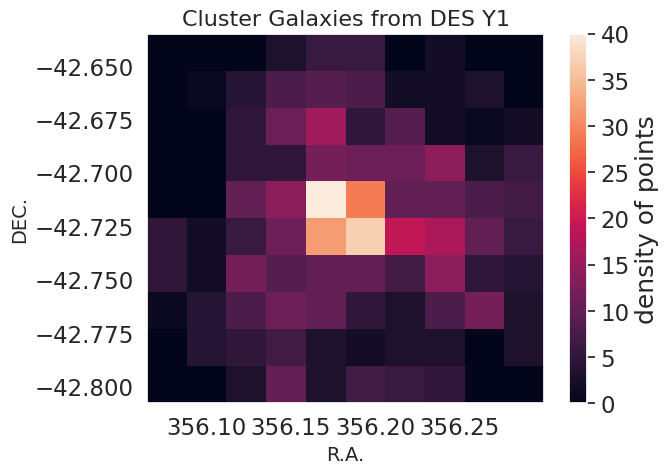

In [151]:
%%time
plt.figure(dpi=100)
plt.hist2d(cluster1.ra, cluster1.dec) # hist2d ao invés de plot
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.colorbar(label="density of points")
plt.tight_layout
# Esse código faz bins no eixo x e bins no eixo y, além de contar quantos objetos tem dentro de cada bin


CPU times: user 32.3 ms, sys: 958 µs, total: 33.3 ms
Wall time: 33.8 ms


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

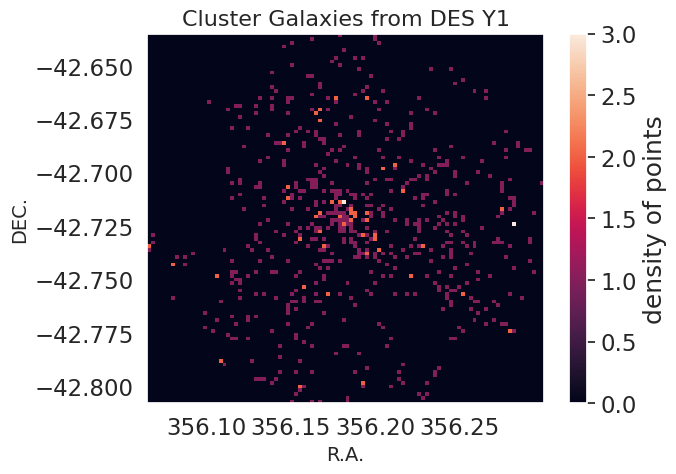

In [152]:
%%time
plt.figure(dpi=100)
plt.hist2d(cluster1.ra, cluster1.dec, bins=100) # Tamanho do bin fica pequeno, aumentando a resolução
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.colorbar(label="density of points")
plt.tight_layout

Hexbin

CPU times: user 539 ms, sys: 3.91 ms, total: 543 ms
Wall time: 556 ms


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

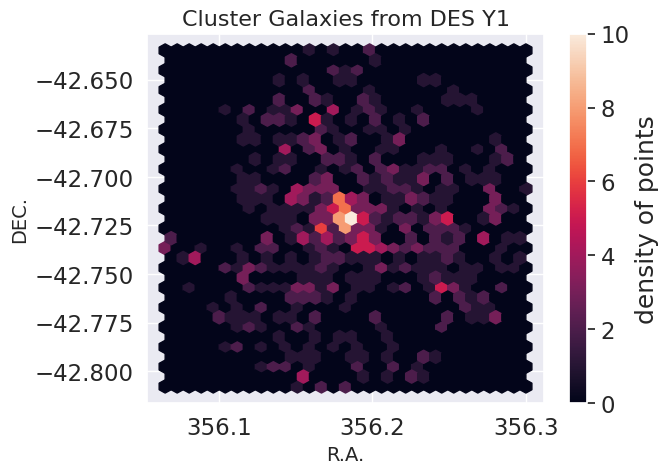

In [153]:
%%time
plt.figure(dpi=100)
plt.hexbin(cluster1.ra, cluster1.dec, gridsize=30) # hexbin no lugar de plot
plt.xlabel("R.A.", fontsize=14)
plt.ylabel("DEC.", fontsize=14)
plt.title("Cluster Galaxies from DES Y1", fontsize=16)
plt.colorbar(label="density of points")
plt.tight_layout
# Ele faz hexágonos, as vezes assim fica mais agradável do que quadrados

# 3. CMD

Cálculo da cor

In [ ]:
dados["gmi"] = (dados.mag_g - dados.mag_i) # calculando a cor
# gmi significa g-i
dados

,obj_id,ra,dec,z_gal,z_cluster,n_gals,mag_g,mag_r,mag_i,mag_z,mag_y,gmi
0,161155,43.687638,-58.985581,0.483762,0.421065,263.8428,23.253954,22.224186,22.088303,22.003595,22.561129,1.165651
1,161156,43.627321,-58.833762,0.573784,0.421065,263.8428,22.958794,22.013378,21.562824,21.240536,20.883377,1.395970
2,161157,43.550251,-58.979774,0.415583,0.421065,263.8428,22.091076,20.356499,19.780567,19.422976,19.240734,2.310509
3,161158,43.761604,-58.938851,0.552824,0.421065,263.8428,21.797768,21.155682,20.791380,20.776703,20.670448,1.006388
4,161159,43.600389,-58.909786,0.407436,0.421065,263.8428,22.366661,20.615086,20.053463,19.695760,19.527836,2.313198
...,...,...,...,...,...,...,...,...,...,...,...,...
1925,1863369,20.784276,-48.308417,0.714422,0.678612,256.1052,22.947355,22.314896,21.722788,21.641348,21.272440,1.224567
1926,1863370,20.743313,-48.399183,0.790175,0.678612,256.1052,23.846120,23.464733,22.865480,23.275509,21.738970,0.980640
1927,1863371,20.738170,-48.373965,0.779717,0.678612,256.1052,25.205189,23.980013,22.822966,22.446396,22.027058,2.382223
1928,1863372,20.761945,-48.364452,0.713890,0.678612,256.1052,26.424408,23.799826,22.520823,22.128416,22.068663,3.903585


Seleção de objetos em uma faixa estreita de redshift.

In [ ]:
zmin = 0.5
zmax = 0.6
# Queremos galáxias aproximadamente a mesma distância
# Então damos uma faixa do redshift (z_gal)
print(f'z_gal > {zmin} & z_gal < {zmax}')# & significa "e"; | significa "ou"

z_gal > 0.5 & z_gal < 0.6


In [ ]:
same_distance = dados.query(f'z_gal > {zmin} & z_gal < {zmax}')
# Query significa consulta, e nesse caso fizemos uma query de todos os 4 clusters, além de dados naquela faixa do redshift

In [ ]:
same_distance.ra.size
# Ficamos com um DataFrame de 510 linhas ou pontinhos para plotar qualquer gráfico sem demorar muito

510

CMD

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

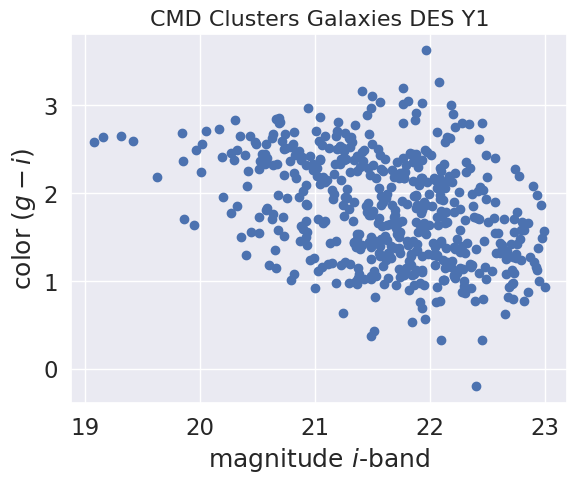

In [154]:
plt.figure(dpi=100)
plt.plot(same_distance['mag_i'], same_distance['mag_g'] - same_distance['mag_i'], "o")
plt.xlabel("magnitude $i$-band")
plt.ylabel("color $(g-i$)")
plt.title("CMD Clusters Galaxies DES Y1", fontsize=16)
plt.tight_layout

Red and blue

In [ ]:
red = same_distance.query('gmi > 2 & gmi < 5')
blue = same_distance.query('gmi > -1 & gmi < 2')

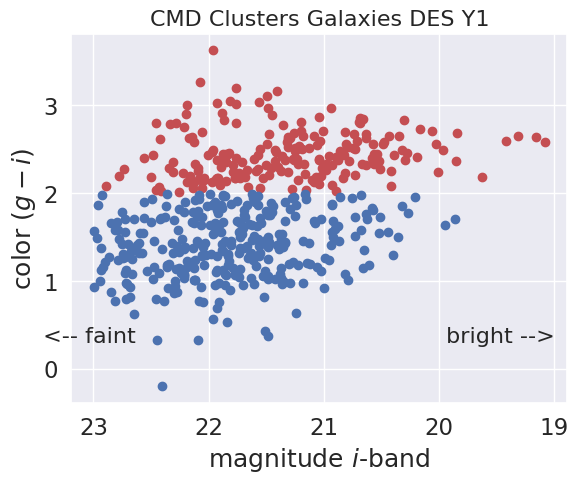

In [155]:
plt.figure(dpi=100)
plt.plot(red['mag_i'], red['mag_g'] - red['mag_i'], "ro")
plt.plot(blue['mag_i'], blue['mag_g'] - blue['mag_i'], "o")
plt.xlabel("magnitude $i$-band")
plt.ylabel("color $(g-i$)")
plt.text(23.5, 0.3, " <-- faint", fontsize=16)
plt.text(20, 0.3, " bright -->", fontsize=16)
plt.title("CMD Clusters Galaxies DES Y1", fontsize=16)
plt.gca().invert_xaxis()
plt.tight_layout
plt.savefig("cmd_cluster_galaxies.png", bbox_inches='tight')

# 4. Export  

Para exportar um notebook com resultados para uma versão estática e leve que abre em qualquer navegador, basta ir no menu em:

`File > Export Notebook As > Export to HTML`

Antes de salvar o arquivo **.ipynb**, não se esqueça de limpar todos os outputs:

`Edit > Clear All Outputs`